core           INFO 	Loading data for British Grand Prix - Qualifying [v3.5.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

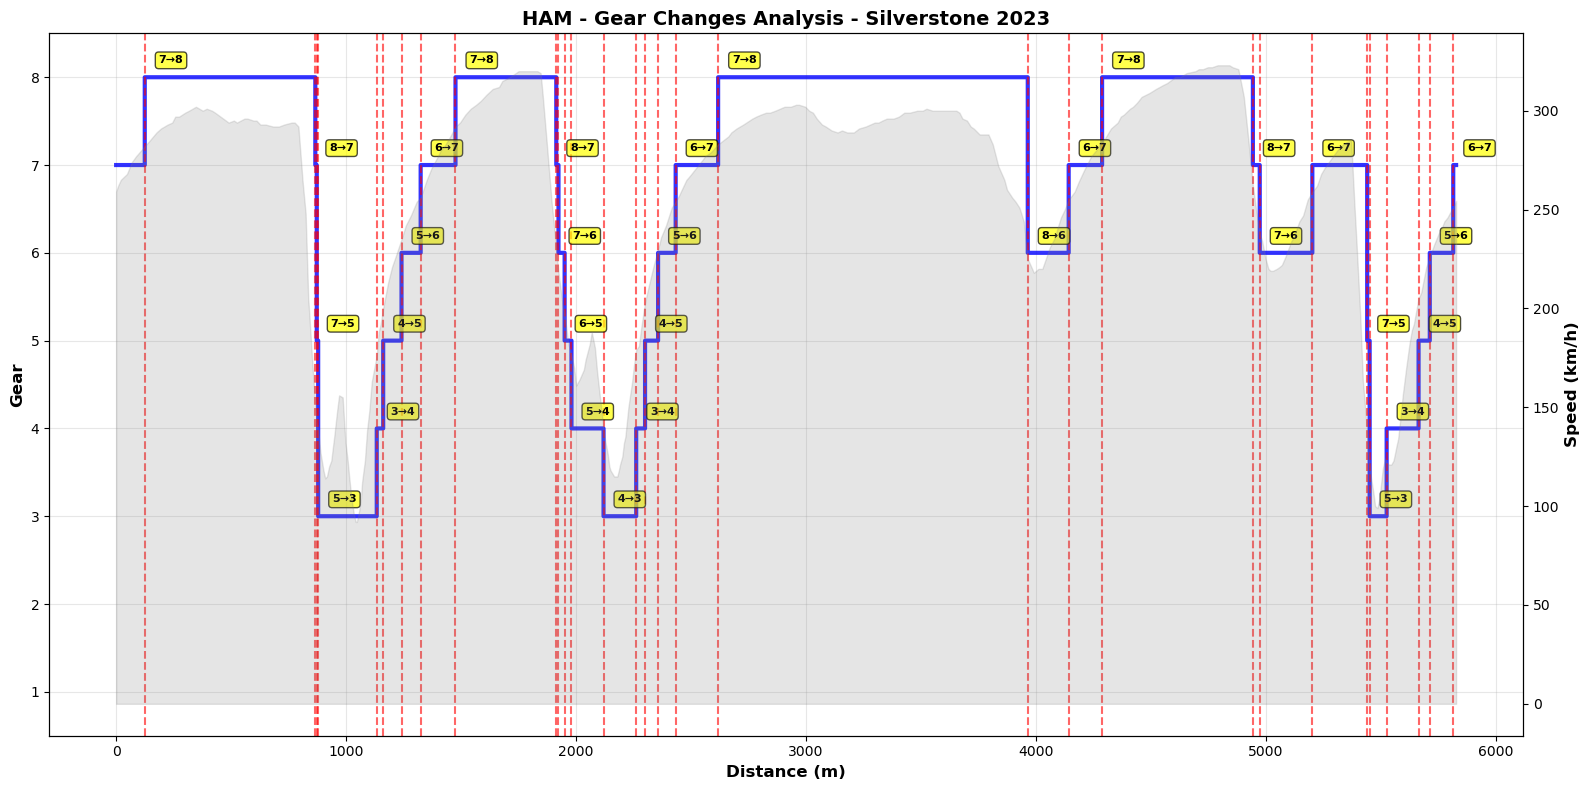


Gear Changes: 31


In [20]:
def plot_gear_with_corners(year, gp, session_type, driver, lap_number=None):
    """Enhanced version that shows gear changes at corners"""
    
    session = fastf1.get_session(year, gp, session_type)
    session.load()
    
    driver_laps = session.laps.pick_driver(driver)
    fastest_lap = driver_laps.pick_fastest() if lap_number is None else \
                  driver_laps[driver_laps['LapNumber'] == lap_number].iloc[0]
    
    telemetry = fastest_lap.get_telemetry()
    
    # Calculate gear changes
    gear_changes = []
    for i in range(1, len(telemetry)):
        if telemetry.iloc[i]['nGear'] != telemetry.iloc[i-1]['nGear']:
            gear_changes.append({
                'distance': telemetry.iloc[i]['Distance'],
                'from_gear': telemetry.iloc[i-1]['nGear'],
                'to_gear': telemetry.iloc[i]['nGear'],
                'speed': telemetry.iloc[i]['Speed']
            })
    
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Plot gear as step function
    ax.step(telemetry['Distance'], telemetry['nGear'], 
            where='post', linewidth=3, color='blue', alpha=0.8)
    
    # Highlight gear changes
    for change in gear_changes:
        ax.axvline(x=change['distance'], color='red', alpha=0.6, linestyle='--')
        ax.annotate(f"{int(change['from_gear'])}→{int(change['to_gear'])}", 
                   xy=(change['distance'], change['to_gear']),
                   xytext=(10, 10), textcoords='offset points',
                   fontsize=8, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    # Add speed as background
    ax2 = ax.twinx()
    ax2.fill_between(telemetry['Distance'], telemetry['Speed'], 
                     alpha=0.2, color='gray', label='Speed')
    
    ax.set_xlabel('Distance (m)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Gear', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Speed (km/h)', fontsize=12, fontweight='bold')
    ax.set_title(f'{driver} - Gear Changes Analysis - {gp} {year}', 
                 fontsize=14, fontweight='bold')
    
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.5, 8.5)
    ax.set_yticks(range(1, 9))
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nGear Changes: {len(gear_changes)}")
    return telemetry, gear_changes

# Run it
telemetry, changes = plot_gear_with_corners(2023, 'Silverstone', 'Q', 'HAM')

core           INFO 	Loading data for Singapore Grand Prix - Qualifying [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '44', '63', '81', '27', '14', '22', '16', '55', '23', '43', '11', '20', '31', '3', '18', '10', '77', '24']


DriverLaps:                      Time Driver DriverNumber                LapTime  \
16 0 days 00:21:29.357000    VER            1                    NaT   
17 0 days 00:23:00.211000    VER            1 0 days 00:01:30.854000   
18 0 days 00:24:59.831000    VER            1 0 days 00:01:59.620000   
19 0 days 00:29:24.241000    VER            1                    NaT   
20 0 days 00:30:54.398000    VER            1 0 days 00:01:30.157000   
21 0 days 00:33:03.446000    VER            1 0 days 00:02:09.048000   
22 0 days 00:40:50.775000    VER            1                    NaT   
23 0 days 00:42:21.146000    VER            1 0 days 00:01:30.371000   
24 0 days 00:44:19.023000    VER            1 0 days 00:01:57.877000   
25 0 days 00:48:56.603000    VER            1                    NaT   
26 0 days 00:50:26.283000    VER            1 0 days 00:01:29.680000   
27 0 days 00:53:16.950000    VER            1                    NaT   
28 0 days 01:04:12.431000    VER            1       

/Users/will/.miniconda3/envs/f1/lib/python3.10/site-packages/fastf1/core.py:3067: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


TypeError: 'NoneType' object is not subscriptable

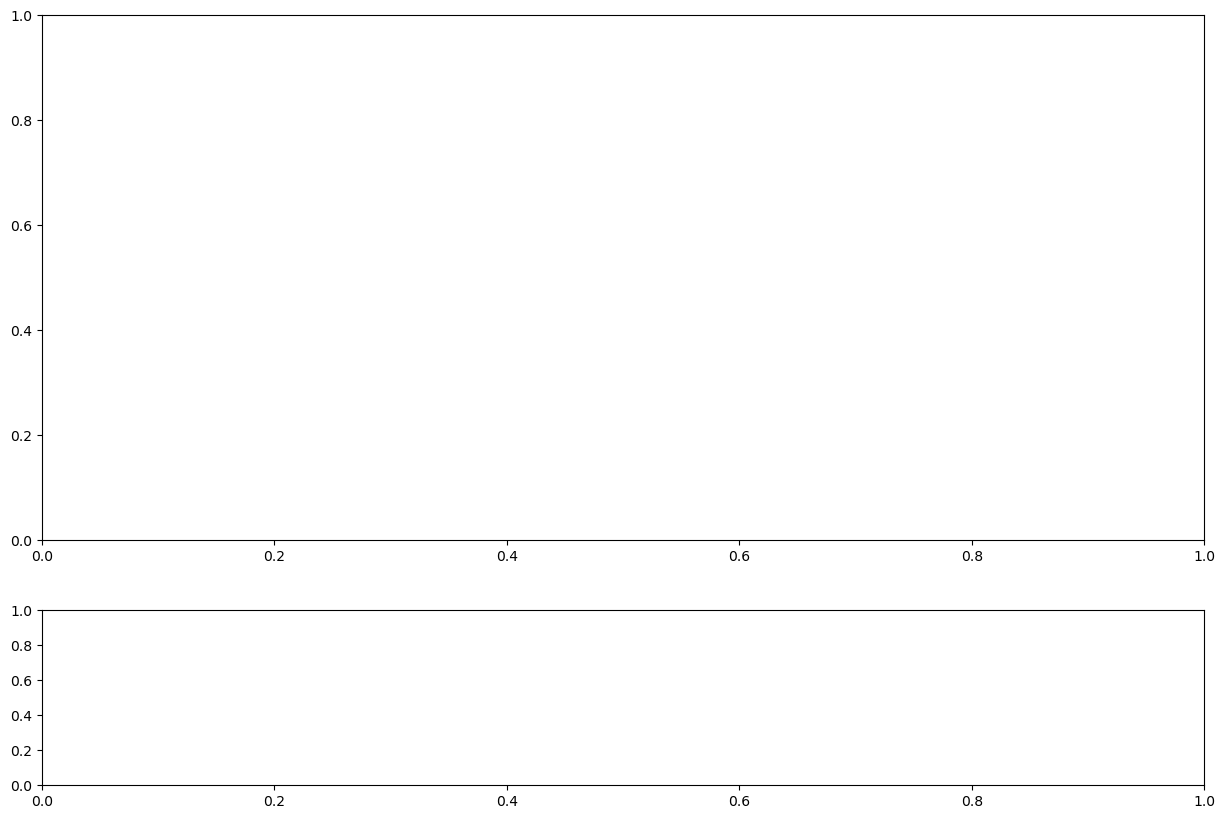

In [18]:
plot_gear_usage(2024,'Singapore', 'Q', 'VER')['X']

In [16]:
xs